In [11]:
import mlflow
import dagshub
import joblib

In [12]:
# Dags Hub Variáveis
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-1"

# Nome do experimento no MLflow
EXPERIMENT_NAME = "Churn-Predict-Telco"

In [13]:
# Configuração de Rastreabilidade atrabés do MLflow + DagsHub
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-1"

Repository JosueJNLui/fiap-mlet-challenge-fase-1 initialized!

## Comparando as métricas frente ao Dataset de Validação - Treino vs Validação

In [14]:
modelos = ["DummyClassifier_kfold_validation", "LogisticRegression_kfold_validation", "RandomForest_kfold_validation", 
            "MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8", # MLP_8_lr0.01_drp0.15_b128 
            "MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32", # MLP_32_lr0.001_drp0.3_b32
            "MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8"    # MLP_8_lr0.01_drp0.3_b64
            ]

In [15]:
# Buscamos apenas apenas as Runs desejadas (top 3 MLPs + baselines)
df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string="tags.mlflow.user = 'josuejnlui'")

df_final = df_runs.set_index('tags.mlflow.runName').loc[modelos]

# Selecionando apenas o essencial para a monografia
tabela_tese = df_final[[
    'metrics.roc_auc', 
    'metrics.pr_auc',
    'metrics.recall',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL', 
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL'
]]

display(tabela_tese)

,metrics.roc_auc,metrics.pr_auc,metrics.recall,metrics.f1_score,metrics.accuracy,metrics.precision,metrics.lucro_liquido_BRL,metrics.custo_churn_perdido_BRL,metrics.custo_falso_positivo_BRL
tags.mlflow.runName,,,,,,,,,
DummyClassifier_kfold_validation,0.500000,0.632676,0.000000,0.000000,0.734647,0.000000,-74750.0,74750.0,0.0
LogisticRegression_kfold_validation,0.849513,0.670088,0.964523,0.565084,0.601729,0.401101,33120.0,2650.0,21910.0
RandomForest_kfold_validation,0.841290,0.656566,0.957199,0.563662,0.603483,0.400562,32340.0,3200.0,21700.0
MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8,0.847806,0.668916,0.956515,0.573265,0.618751,0.410650,33120.0,3250.0,20830.0
MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32,0.846366,0.669048,0.959893,0.568297,0.611282,0.404296,33100.0,3000.0,21300.0
MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8,0.849074,0.672938,0.955817,0.572711,0.617693,0.410464,32980.0,3300.0,20880.0


### Embora as arquiteturas de redes neurais (MLP) tenham apresentado métricas de precisão e F1-Score levemente superiores, a Regressão Logística foi selecionada como o modelo de produção final. Esta decisão fundamenta-se no princípio da parcimônia: diante de um empate técnico no lucro líquido médio (R$ 33.120,00) validado pelo teste de Nemenyi, a Regressão Logística oferece maior interpretabilidade dos fatores determinantes do churn e menor custo operacional de manutenção e deploy (MLOps), garantindo uma solução robusta e transparente para as estratégias de retenção da companhia

## Comparando as métricas frente ao Dataset de Teste - (Treino + Validação) vs Teste

In [16]:
modelos = ["DummyClassifier", "LogisticRegression", "RandomForest", "MLP_GridSearch_KFold"]

In [17]:
# Buscamos apenas apenas as Runs desejadas (top 3 MLPs + baselines)
df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string="tags.mlflow.user = 'josuejnlui'")

df_final = df_runs.set_index('tags.mlflow.runName').loc[modelos]

# Selecionando apenas o essencial para a monografia
tabela_tese = df_final[[
    'metrics.roc_auc', 
    'metrics.recall',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL', 
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL',
]]

display(tabela_tese)

,metrics.roc_auc,metrics.recall,metrics.f1_score,metrics.accuracy,metrics.precision,metrics.lucro_liquido_BRL,metrics.custo_churn_perdido_BRL,metrics.custo_falso_positivo_BRL
tags.mlflow.runName,,,,,,,,
DummyClassifier,0.500000,0.000000,0.000000,0.734564,0.000000,-187000.0,187000.0,0.0
LogisticRegression,0.849089,0.959893,0.560062,0.599716,0.395374,81200.0,7500.0,54900.0
RandomForest,0.840492,0.954545,0.550926,0.586941,0.387202,77800.0,8500.0,56500.0
MLP_GridSearch_KFold,0.846648,0.973262,0.540460,0.560681,0.374101,79700.0,5000.0,60900.0


### A avaliação final no conjunto de teste (hold-out) ratificou a Regressão Logística como o modelo superior. Enquanto a Rede Neural (MLP) demonstrou uma tendência ao aumento de falsos positivos quando exposta a dados inéditos — elevando os custos operacionais de retenção para R$ 60.900,00 — a Regressão Logística manteve sua estabilidade estatística. O modelo linear alcançou o maior lucro líquido final (R$ 81.200,00), superando a MLP em 1,8% e a Random Forest em 4,3%, provando que, para este problema de negócio, a simplicidade estrutural resultou em uma capacidade de generalização financeira superior.

###### Melhores MLPs, 1 Dummy, 1 Regressão Logística, 1 Árvore -> Gráfico de barras, Tabelas

In [18]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt


# 1. Buscar runs do MLflow

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

df_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id], filter_string="tags.mlflow.user = 'josuejnlui'"
)


# 2. Modelos esperados

modelos = [
    "DummyClassifier_kfold_validation",
    "LogisticRegression_kfold_validation",
    "RandomForest_kfold_validation",
    "MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8",
    "MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32",
    "MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8"
]


#DEBUG (IMPORTANTE)

print("Modelos disponíveis no MLflow:")
print(df_runs["tags.mlflow.runName"].unique())


# 3. Filtrar apenas os que EXISTEM

modelos_existentes = [
    m for m in modelos if m in df_runs["tags.mlflow.runName"].values
]

print("\nModelos encontrados:")
print(modelos_existentes)


# 4. Filtrar dataframe
df = df_runs[df_runs["tags.mlflow.runName"].isin(modelos_existentes)]


# 5. Garantir 1 linha por modelo

df = (
    df.sort_values(by="metrics.lucro_liquido_BRL", ascending=False)
      .drop_duplicates(subset="tags.mlflow.runName")
      .set_index("tags.mlflow.runName")
)


# 6. Criar tabela

tabela = df[[
    'metrics.roc_auc',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL',
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL'
]].copy()

# 7. Renomear (dinâmico)

map_nomes = {
    "DummyClassifier_kfold_validation": "Dummy",
    "LogisticRegression_kfold_validation": "Logistic Regression",
    "RandomForest_kfold_validation": "Random Forest",
}

# MLP dinâmico
mlp_count = 1
for idx in tabela.index:
    if "MLP" in idx:
        map_nomes[idx] = f"MLP (Top {mlp_count})"
        mlp_count += 1

tabela = tabela.rename(index=map_nomes)

# 8. Renomear colunas
tabela = tabela.rename(columns={
    'metrics.roc_auc': 'AUC',
    'metrics.f1_score': 'F1',
    'metrics.accuracy': 'Accuracy',
    'metrics.precision': 'Precision',
    'metrics.lucro_liquido_BRL': 'Lucro',
    'metrics.custo_churn_perdido_BRL': 'Custo_Churn_Perdido',
    'metrics.custo_falso_positivo_BRL': 'Custo_Falso_Positivo'
})

print("\n Tabela Final:")
tabela = tabela.sort_values(by="Lucro", ascending=False)
display(tabela)

Modelos disponíveis no MLflow:
['MLP_lr=0.001_dropout=0.3_batch=128_hidden_dims=8'
 'MLP_lr=0.001_dropout=0.3_batch=128_hidden_dims=16'
 'MLP_lr=0.001_dropout=0.3_batch=128_hidden_dims=32'
 'MLP_lr=0.001_dropout=0.3_batch=64_hidden_dims=8'
 'MLP_lr=0.001_dropout=0.3_batch=64_hidden_dims=16'
 'MLP_lr=0.001_dropout=0.3_batch=64_hidden_dims=32'
 'MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=8'
 'MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=16'
 'MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32'
 'MLP_lr=0.001_dropout=0.15_batch=128_hidden_dims=8'
 'MLP_lr=0.001_dropout=0.15_batch=128_hidden_dims=16'
 'MLP_lr=0.001_dropout=0.15_batch=128_hidden_dims=32'
 'MLP_lr=0.001_dropout=0.15_batch=64_hidden_dims=8'
 'MLP_lr=0.001_dropout=0.15_batch=64_hidden_dims=16'
 'MLP_lr=0.001_dropout=0.15_batch=64_hidden_dims=32'
 'MLP_lr=0.001_dropout=0.15_batch=32_hidden_dims=8'
 'MLP_lr=0.001_dropout=0.15_batch=32_hidden_dims=16'
 'MLP_lr=0.001_dropout=0.15_batch=32_hidden_dims=32'
 'MLP_lr=0.001_dropout=0

,AUC,F1,Accuracy,Precision,Lucro,Custo_Churn_Perdido,Custo_Falso_Positivo
tags.mlflow.runName,,,,,,,
Logistic Regression,0.849513,0.565084,0.601729,0.401101,33120.0,2650.0,21910.0
MLP (Top 1),0.847806,0.573265,0.618751,0.410650,33120.0,3250.0,20830.0
MLP (Top 2),0.846366,0.568297,0.611282,0.404296,33100.0,3000.0,21300.0
MLP (Top 3),0.849074,0.572711,0.617693,0.410464,32980.0,3300.0,20880.0
Random Forest,0.841290,0.563662,0.603483,0.400562,32340.0,3200.0,21700.0
Dummy,0.500000,0.000000,0.734647,0.000000,-74750.0,74750.0,0.0


### GRÁFICO DE LUCRO

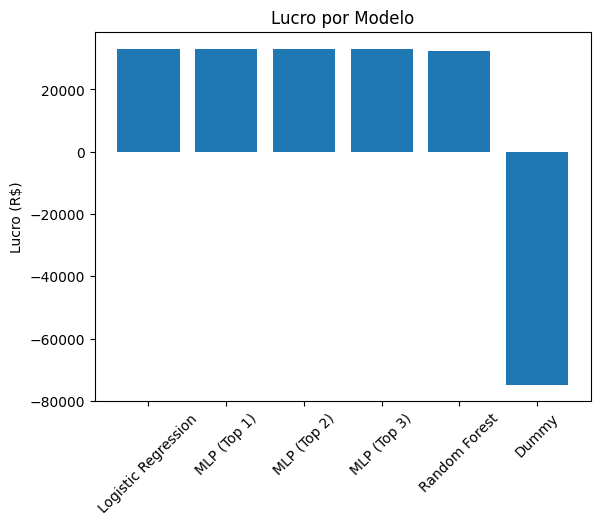

In [19]:
plt.figure()
plt.bar(tabela.index, tabela["Lucro"])

plt.title("Lucro por Modelo")
plt.ylabel("Lucro (R$)")
plt.xticks(rotation=45)

plt.show()

### GRÁFICO DE PERFORMANCE (AUC)

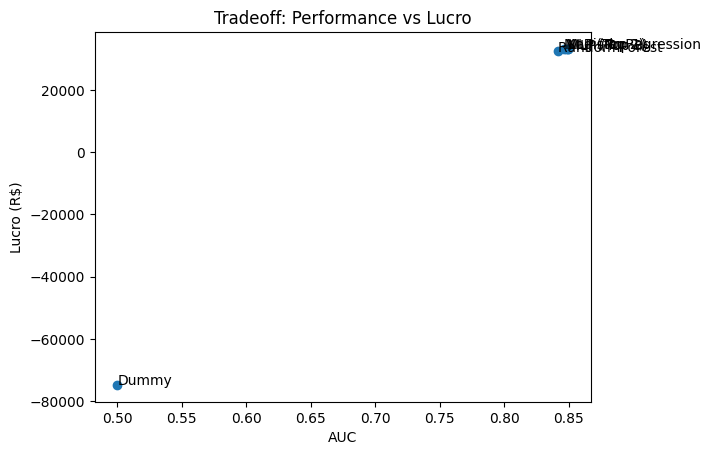

In [20]:

#  Gráfico 2 - Tradeoff (AUC vs Lucro)

plt.figure()

plt.scatter(tabela["AUC"], tabela["Lucro"])

for i, txt in enumerate(tabela.index):
    plt.annotate(txt, (tabela["AUC"].iloc[i], tabela["Lucro"].iloc[i]))

plt.title("Tradeoff: Performance vs Lucro")
plt.xlabel("AUC")
plt.ylabel("Lucro (R$)")

plt.show()

### GRÁFICO  TRADEOFF (OURO)

/tmp/ipykernel_8988/296814840.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (tabela["AUC"][i], tabela["Lucro"][i]))


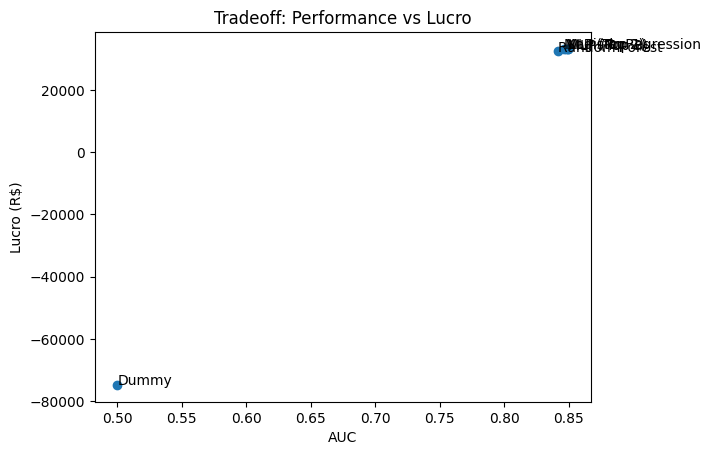

In [21]:
plt.figure()

plt.scatter(tabela["AUC"], tabela["Lucro"])

for i, txt in enumerate(tabela.index):
    plt.annotate(txt, (tabela["AUC"][i], tabela["Lucro"][i]))

plt.title("Tradeoff: Performance vs Lucro")
plt.xlabel("AUC")
plt.ylabel("Lucro (R$)")
plt.show()

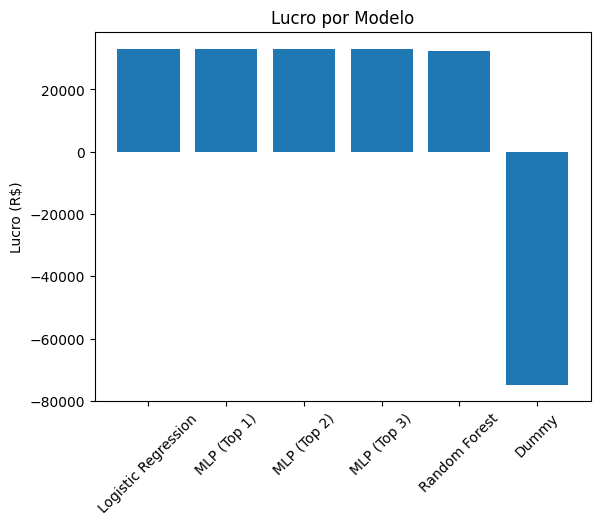

In [22]:
plt.figure()
plt.bar(tabela.index, tabela["Lucro"])
plt.title("Lucro por Modelo")
plt.ylabel("Lucro (R$)")
plt.xticks(rotation=45)
plt.show()